## Import the required Modules

In [101]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid") 
import plotly.express as px

## Loading of the dataset
#### Choosing Hotel Bookings dataset from Kaggle

In [102]:
df = pd.read_csv("hotel_bookings.csv")

In [103]:
print('Info on the dataset:')
display(df.info())

Info on the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  


None

In [104]:
pd.set_option('display.max_columns', None)

In [105]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [106]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [107]:
print(f'Shape of the Data, {df.shape}')

Shape of the Data, (119390, 32)


<span style="font-size:12px;">Based on the below output, we need to change some datatypes.</span>

In [108]:
print(f'Datatypes of each column, \n {df.dtypes}')

Datatypes of each column, 
 hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent 

In [109]:
print('Unique values of each columns with their datatypes to decide whether the category of column')
j=1
for i in df.columns:
    print('-----------------------------------------------------------------------------')
    print('Column: ', j)
    print(i, df[i].dtype)
    print(df[i].unique())
    print('-----------------------------------------------------------------------------')
    j+=1

Unique values of each columns with their datatypes to decide whether the category of column
-----------------------------------------------------------------------------
Column:  1
hotel object
['Resort Hotel' 'City Hotel']
-----------------------------------------------------------------------------
-----------------------------------------------------------------------------
Column:  2
is_canceled int64
[0 1]
-----------------------------------------------------------------------------
-----------------------------------------------------------------------------
Column:  3
lead_time int64
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 

<span style="font-size:15px;">Inherent default conversion of the columns to their appropriate datatypes.</span>


In [110]:
df = df.convert_dtypes() 

In [111]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  string 
 1   is_canceled                     119390 non-null  Int64  
 2   lead_time                       119390 non-null  Int64  
 3   arrival_date_year               119390 non-null  Int64  
 4   arrival_date_month              119390 non-null  string 
 5   arrival_date_week_number        119390 non-null  Int64  
 6   arrival_date_day_of_month       119390 non-null  Int64  
 7   stays_in_weekend_nights         119390 non-null  Int64  
 8   stays_in_week_nights            119390 non-null  Int64  
 9   adults                          119390 non-null  Int64  
 10  children                        119386 non-null  Int64  
 11  babies                          119390 non-null  Int64  
 12  meal            

None

In [112]:
df.dtypes

hotel                             string[python]
is_canceled                                Int64
lead_time                                  Int64
arrival_date_year                          Int64
arrival_date_month                string[python]
arrival_date_week_number                   Int64
arrival_date_day_of_month                  Int64
stays_in_weekend_nights                    Int64
stays_in_week_nights                       Int64
adults                                     Int64
children                                   Int64
babies                                     Int64
meal                              string[python]
country                           string[python]
market_segment                    string[python]
distribution_channel              string[python]
is_repeated_guest                          Int64
previous_cancellations                     Int64
previous_bookings_not_canceled             Int64
reserved_room_type                string[python]
assigned_room_type  

#### Column Hotel
Hotel has 2 values. City Hotel and Resort Hotel
These are actually names of the 2 hotels in Portugal

In [113]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,<NA>,<NA>,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,<NA>,<NA>,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,<NA>,<NA>,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,<NA>,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,<NA>,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [114]:
df.dtypes

hotel                             string[python]
is_canceled                                Int64
lead_time                                  Int64
arrival_date_year                          Int64
arrival_date_month                string[python]
arrival_date_week_number                   Int64
arrival_date_day_of_month                  Int64
stays_in_weekend_nights                    Int64
stays_in_week_nights                       Int64
adults                                     Int64
children                                   Int64
babies                                     Int64
meal                              string[python]
country                           string[python]
market_segment                    string[python]
distribution_channel              string[python]
is_repeated_guest                          Int64
previous_cancellations                     Int64
previous_bookings_not_canceled             Int64
reserved_room_type                string[python]
assigned_room_type  

In [115]:
print('"is_canceled" and "is_repeated_guest" look like booleans and have 2 values, 1 and 0. Hence converting it to boolean for effective analysis')
df[['is_canceled', 'is_repeated_guest']] = df[['is_canceled', 'is_repeated_guest']].astype(bool)

"is_canceled" and "is_repeated_guest" look like booleans and have 2 values, 1 and 0. Hence converting it to boolean for effective analysis


Now you see the final datatypes of each columns below

In [116]:
df.dtypes

hotel                             string[python]
is_canceled                                 bool
lead_time                                  Int64
arrival_date_year                          Int64
arrival_date_month                string[python]
arrival_date_week_number                   Int64
arrival_date_day_of_month                  Int64
stays_in_weekend_nights                    Int64
stays_in_week_nights                       Int64
adults                                     Int64
children                                   Int64
babies                                     Int64
meal                              string[python]
country                           string[python]
market_segment                    string[python]
distribution_channel              string[python]
is_repeated_guest                           bool
previous_cancellations                     Int64
previous_bookings_not_canceled             Int64
reserved_room_type                string[python]
assigned_room_type  

In [117]:
#Find data shape and no of colomns
print(df.shape)
df.columns

(119390, 32)


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### SUMMARY STATISTICS

In [118]:
print('-----SUMMARY STATISTICS-----')
display(df.describe(include='all'))

-----SUMMARY STATISTICS-----


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390,119390.0,119390.0,119390,119390.0,119390.0,119390.0,119390.0,119390.0,119386.0,119390.0,119390,118902,119390,119390,119390,119390.0,119390.0,119390,119390,119390.0,119390,103050.0,6797.0,119390.0,119390,119390.0,119390.0,119390.0,119390,119390
unique,2,2,<NA>,<NA>,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5,177,8,5,2,<NA>,<NA>,10,12,<NA>,3,<NA>,<NA>,<NA>,4,<NA>,<NA>,<NA>,3,926
top,City Hotel,False,<NA>,<NA>,August,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,BB,PRT,Online TA,TA/TO,False,<NA>,<NA>,A,A,<NA>,No Deposit,<NA>,<NA>,<NA>,Transient,<NA>,<NA>,<NA>,Check-Out,2015-10-21
freq,79330,75166,<NA>,<NA>,13877,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,92310,48590,56477,97870,115580,<NA>,<NA>,85994,74053,<NA>,104641,<NA>,<NA>,<NA>,89613,<NA>,<NA>,<NA>,75166,1461
mean,NaN,NaN,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.10389,0.007949,NaN,NaN,NaN,NaN,NaN,0.087118,0.137097,NaN,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,NaN,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,NaN,0.844336,1.497437,NaN,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.53579,0.245291,0.792798,NaN,NaN
min,NaN,NaN,0.0,2015.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,1.0,6.0,0.0,NaN,-6.38,0.0,0.0,NaN,NaN
25%,NaN,NaN,18.0,2016.0,NaN,16.0,8.0,0.0,1.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,9.0,62.0,0.0,NaN,69.29,0.0,0.0,NaN,NaN
50%,NaN,NaN,69.0,2016.0,NaN,28.0,16.0,1.0,2.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,14.0,179.0,0.0,NaN,94.575,0.0,0.0,NaN,NaN
75%,NaN,NaN,160.0,2017.0,NaN,38.0,23.0,2.0,3.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,229.0,270.0,0.0,NaN,126.0,0.0,1.0,NaN,NaN


### Handling Missing Values
<span style="font-size:18px;">Check where we see the missing values and null</span>


In [119]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  string 
 1   is_canceled                     119390 non-null  bool   
 2   lead_time                       119390 non-null  Int64  
 3   arrival_date_year               119390 non-null  Int64  
 4   arrival_date_month              119390 non-null  string 
 5   arrival_date_week_number        119390 non-null  Int64  
 6   arrival_date_day_of_month       119390 non-null  Int64  
 7   stays_in_weekend_nights         119390 non-null  Int64  
 8   stays_in_week_nights            119390 non-null  Int64  
 9   adults                          119390 non-null  Int64  
 10  children                        119386 non-null  Int64  
 11  babies                          119390 non-null  Int64  
 12  meal            

None

<span style="font-size:15px;">Missing values/Nulls can be seen in the below columns and needs handling </span>
1. agent
2. company
3. children
4. country

#### User defined function to handle missing/null values

In [121]:
def cleaningData(df):
    df2 = df.copy()
    print('Filling 0 for nulls in the 2 columns...')
    df2['company'] = df2['company'].fillna(0)
    df2['agent'] = df2['agent'].fillna(0)
    print('Filling "Unknown" for a country that\'s not listed:...')
    df2['country'] = df2['country'].fillna('Unknown')
    print('If the "children" columns has null, probably means they don\'t have children')
    df2['children'] = df2['children'].fillna(0)
    return df2 

In [123]:
df = cleaningData(df)
print('Cleaned data:')
display(df.info())

Filling 0 for nulls in the 2 columns...
Filling "Unknown" for a country that's not listed:...
If the "children" columns has null, probably means they don't have children
Cleaned data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  string 
 1   is_canceled                     119390 non-null  bool   
 2   lead_time                       119390 non-null  Int64  
 3   arrival_date_year               119390 non-null  Int64  
 4   arrival_date_month              119390 non-null  string 
 5   arrival_date_week_number        119390 non-null  Int64  
 6   arrival_date_day_of_month       119390 non-null  Int64  
 7   stays_in_weekend_nights         119390 non-null  Int64  
 8   stays_in_week_nights            119390 non-null  Int64  
 9   adults            

None

In [124]:
df.shape

(119390, 32)

<span style="font-size:16px;"> Conversion of datatype </span> <br>
Handling Arrival date and date conversions

In [129]:
df['arrival_date'] = df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'].astype(str) + '-' + df['arrival_date_day_of_month'].astype(str) 
df['arrival_date'] = pd.to_datetime(df['arrival_date'], errors='coerce')
print(f'Datatype of the new columns is now: {df['arrival_date'].dtype}')
print(f'Arrival Time usual form:') 
df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date']].head()


Datatype of the new columns is now: datetime64[ns]
Arrival Time usual form:


,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


In [131]:
print('"agent" is actually ID of the Agent. It would be treated as integer which will make it seem like a numeric columns. Hence, changing its datatype to string')
df[['agent']] = df[['agent']].astype(str)

"agent" is actually ID of the Agent. It would be treated as integer which will make it seem like a numeric columns. Hence, changing its datatype to string


In [132]:
df.dtypes

hotel                             string[python]
is_canceled                                 bool
lead_time                                  Int64
arrival_date_year                          Int64
arrival_date_month                string[python]
arrival_date_week_number                   Int64
arrival_date_day_of_month                  Int64
stays_in_weekend_nights                    Int64
stays_in_week_nights                       Int64
adults                                     Int64
children                                   Int64
babies                                     Int64
meal                              string[python]
country                           string[python]
market_segment                    string[python]
distribution_channel              string[python]
is_repeated_guest                           bool
previous_cancellations                     Int64
previous_bookings_not_canceled             Int64
reserved_room_type                string[python]
assigned_room_type  

<span style="font-size:16px;"> Check on the story that Categorical Values tells. </span> <br>
Below are the Categorical values:
1. hotel
2. is_canceled
3. arrival_date_month
4. meal
5. country
6. market_segment
7. distribution_channel
8. is_repeated_guest
9. reserved_room_type
10. assigned_room_type
11. desposit_type
12. agent
13. customer_type
14. reservation_status
15. reservation_status_date

What the below code reveals? 
For example, For the column 'hotel', "City Hotel" is the most **frequent** value in the column with a frequency of **79330**

In [134]:
print('Categorical descriptions')
display(df.describe(include=['bool', 'object', 'string[python]']))

Categorical descriptions


,hotel,is_canceled,arrival_date_month,meal,country,market_segment,distribution_channel,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,agent,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,2,12,5,178,8,5,2,10,12,3,334,4,3,926
top,City Hotel,False,August,BB,PRT,Online TA,TA/TO,False,A,A,No Deposit,9,Transient,Check-Out,2015-10-21
freq,79330,75166,13877,92310,48590,56477,97870,115580,85994,74053,104641,31961,89613,75166,1461


Below gives the description of the numeric columns with mean, SD etc

In [146]:
print('Numerical descriptions')
display(df.describe(exclude=['bool', 'object', 'string[python]']))

Numerical descriptions


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date
count,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390
mean,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.087118,0.137097,0.221124,10.775157,2.321149,101.831122,0.062518,0.571363,2016-08-28 16:39:45.727447808
min,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.38,0.0,0.0,2015-07-01 00:00:00
25%,18.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.29,0.0,0.0,2016-03-13 00:00:00
50%,69.0,2016.0,28.0,16.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94.575,0.0,0.0,2016-09-06 00:00:00
75%,160.0,2017.0,38.0,23.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,126.0,0.0,1.0,2017-03-18 00:00:00
max,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,10.0,26.0,72.0,21.0,543.0,391.0,5400.0,8.0,5.0,2017-08-31 00:00:00
std,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.844336,1.497437,0.652306,53.943884,17.594721,50.53579,0.245291,0.792798,NaN


### HISTOGRAM: Distribution of ADR
Most of the booking are clustered around between $50 and $150. 
We see a huge line in the middle which suggests the adr being as high as $5k. This is an outlier and should be excluded from analysis since it's not possible for adr to be high and will skew the average heavily

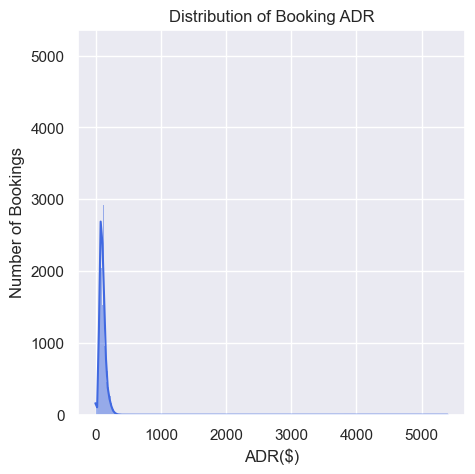

In [154]:
#HISTOGRAM: Distribution of Lead Tim
plt.figure(figsize=(5, 5))
sns.histplot(df['adr'], kde=True, color='royalblue')
plt.title('Distribution of Booking ADR')
plt.xlabel('ADR($)')
plt.ylabel('Number of Bookings')
plt.show()

### BAR PLOT: Bookings by Market Segment
Online TA, ie the Travel Agents like Agoda, ClearTrip and responsible for most bookings. City and Resort Hotels combined.

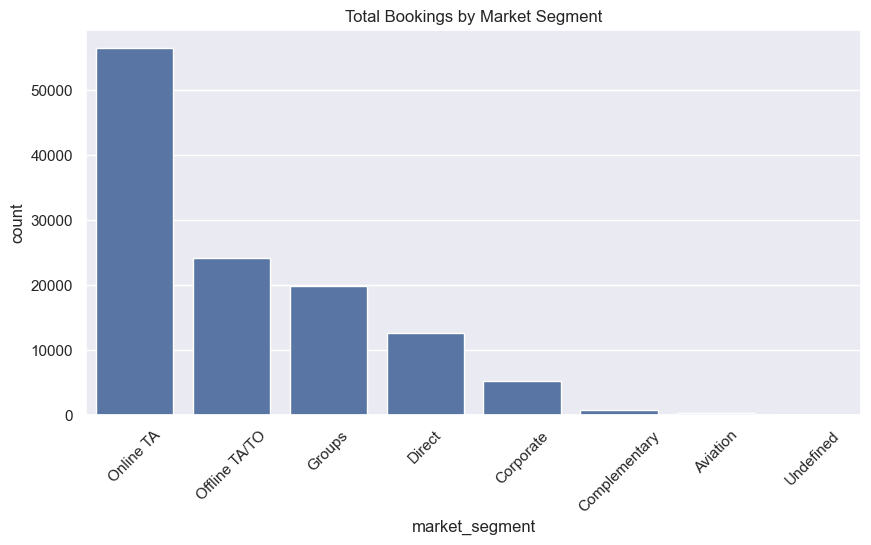

In [156]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='market_segment', order=df['market_segment'].value_counts().index)
plt.title('Total Bookings by Market Segment')
plt.xticks(rotation=45)
plt.show()

### Below Insights that we are after to boost Bookings
Looking into successful bookings and how the guest behaviour changes for these bookings?

Filter out the canceled reservations and outliers

In [215]:
print('Focusing on Actual Revenue, i.e. is_canceled = False and removing outliers')
dfnc = df[(df['is_canceled'] == False) & (dfnc['adr'] < 1000)].copy()
display(dfnc.head())

Focusing on Actual Revenue, i.e. is_canceled = False and removing outliers


C:\Users\monke\AppData\Local\Temp\ipykernel_9496\112085085.py:2: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  dfnc = df[(df['is_canceled'] == False) & (dfnc['adr'] < 1000)].copy()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,False,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,False,0,0,C,C,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,False,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,False,0,0,C,C,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,False,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,False,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,False,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01


In [216]:
print('Total Length of stay')
dfnc['total_stay'] = dfnc['stays_in_weekend_nights'] + dfnc['stays_in_week_nights']
display(dfnc.head())

Total Length of stay


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_stay
0,Resort Hotel,False,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,False,0,0,C,C,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,0
1,Resort Hotel,False,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,False,0,0,C,C,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,0
2,Resort Hotel,False,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1
3,Resort Hotel,False,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1
4,Resort Hotel,False,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2


In [217]:
#Show the graph order by Months. Otherwise, is will show the months on x axis alphabetically
ordered_months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
dfnc['arrival_month'] = pd.Categorical(dfnc['arrival_date_month'], categories=ordered_months, ordered=True)

The outliers for both the Hotels lie heavily in the range > 400. We should Filter this out since it could skew our results. 

C:\Users\monke\AppData\Local\Temp\ipykernel_9496\1905079963.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfnc, x='hotel', y='adr', palette='pastel')


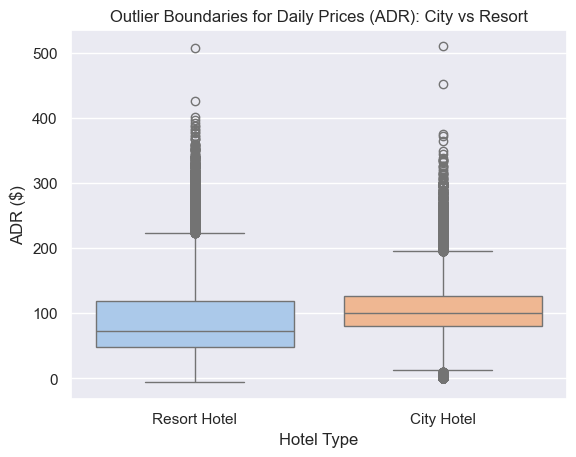

In [218]:

sns.boxplot(data=dfnc, x='hotel', y='adr', palette='pastel')
plt.title('Outlier Boundaries for Daily Prices (ADR): City vs Resort')
plt.xlabel('Hotel Type')
plt.ylabel('ADR ($)')
plt.show()

### Seasonal changes and other effects on Total Bookings and ADR

The Histograms below show the ADR are left skewed for most of the times <br>
Meaning, you could see on average where the numbers lie <br>

1. City Hotel (orange): Shows a much sharper and taller peak around the $100 mark, proving its revenue is highly dependent on a standardized, stable price point
   
2. Resort Hotel (blue): Shows a much wider and flatter distribution, which mathematically proves it uses pricing ranging from very low to very high rates compared to the City Hotel. <br>

   
<span style="font-size:16px;"> Final Observation: The City Hotel follows a nearly Normal Distribution centered at $100, while the Resort Hotel shows higher variance, reflecting its seasonal nature. </span> <br>

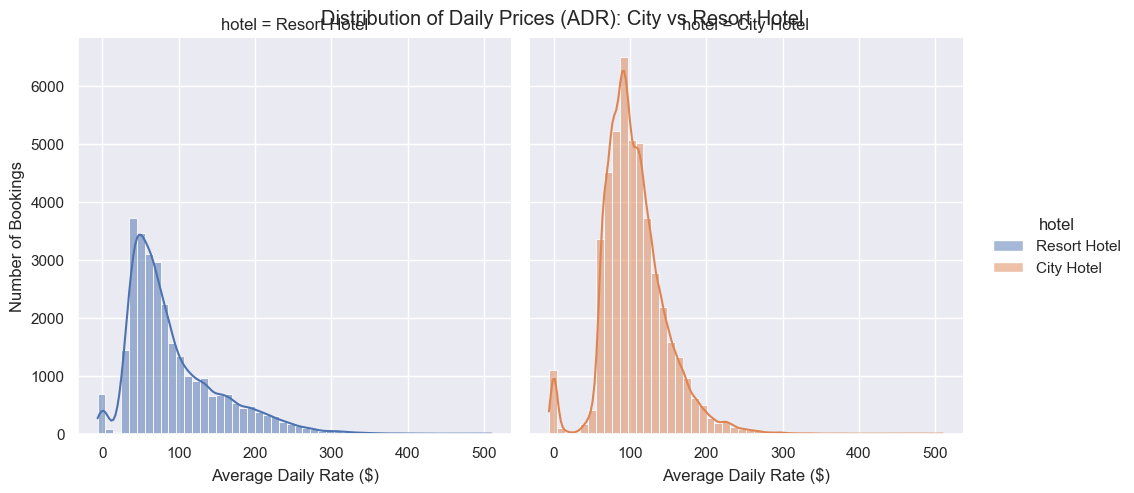

In [220]:
g = sns.displot(
    data=dfnc, 
    x='adr', 
    col='hotel',
    hue='hotel',
    kind='hist',
    bins=50, 
    kde=True
)

g.fig.suptitle('Distribution of Daily Prices (ADR): City vs Resort Hotel')
g.set_axis_labels("Average Daily Rate ($)", "Number of Bookings")
plt.show()

The line plots below show how the adr fluctuates over year. We see Mid-Year to be the most expensive. 
In Portugal, the Summer season is from June to August. 
1. In the City Hotel (left panel), you can clearly see that the 2016 (orange) and 2017 (blue) lines sit significantly higher than the 2015 (green) line. This is visual proof that the hotel successfully scaled its operations and increased its customer base year-over-year.
2. Both hotels show a massive surge in bookings during the May–August window. This confirms that summer is the primary revenue driver for both urban and resort locations, requiring maximum staffing during these months.

### Correlational Analysis
1. **Lead Time VS Total Stay**: People taking longer vacations absolutely book well in advance. That means, if we want those people to stay longer, maybe start advertising the summer offers in winter so that people will book accordingly.
2. **adr VS Lead Time**: Booking well in advance does NOT give you any discounts. Hotels do not give discounts just because a few rooms are empty.
3. **adr VS Adults and Children**: The Daily rooms are almost always driven by no. of people sleeping in it. Profit margins reside when people need extra beds.

The bump that we see mid years should refer to summer season in Portugal. We see that the bump makes sense when we know it's because of the summar holidays
1. The Resort Hotel experiences extreme seasonal pricing volatility. Their ADR starts low around $ 50 in January, peaks massively to roughly $ 180 in August, and drops sharply back to winter rates by November.
2. In contrast, the City Hotel maintains a highly stable pricing strategy year-round. Their ADR gently climbs to a steady plateau of about $ 110 to $ 120 from May through September, without any drastic summer spikes. <br>
**Inference**: Resort Hotels use dynamic, high-variance seasonal pricing to capitalize on summer tourism, whereas City Hotels maintain a flat, stable pricing model suited for constant corporate and transit demand. Resort hotel should up their Summar game because that's whats keeps them going

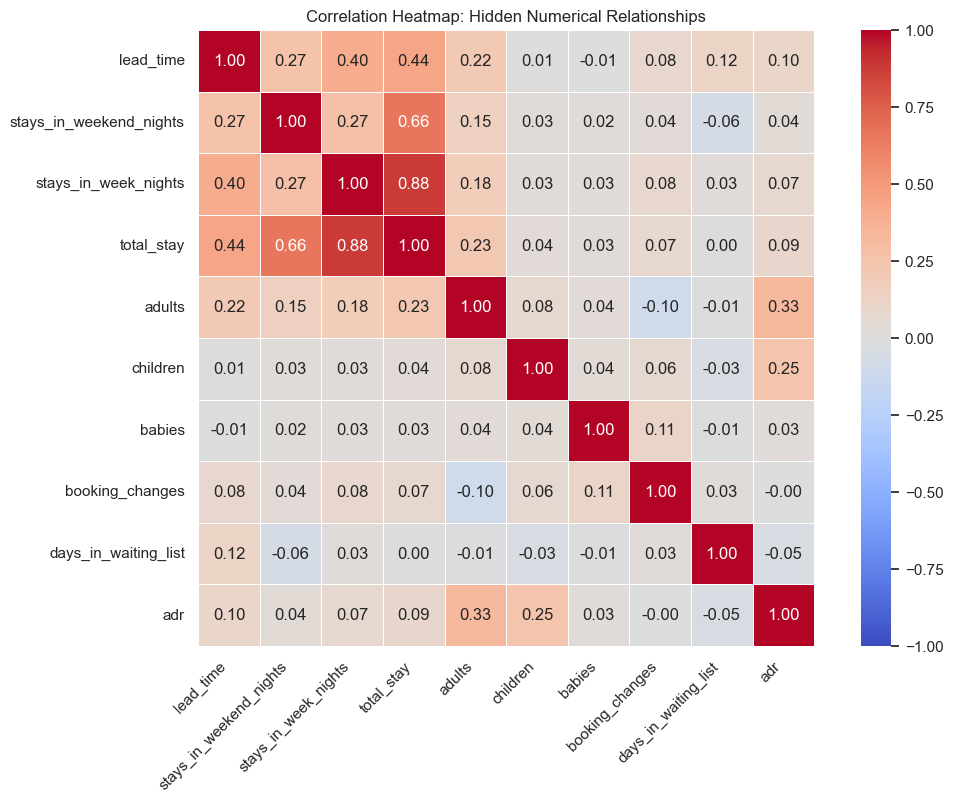

In [219]:
numerical_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_stay',
    'adults', 'children', 'babies', 'booking_changes', 
    'days_in_waiting_list', 'adr'
]

# 3. Calculate the Pearson correlation matrix
corr_matrix = dfnc[numerical_cols].corr(method='spearman')

plt.figure(figsize=(12, 8))


sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm',    # Blue = negative corr, Red = positive corr
    vmin=-1, vmax=1, 
    square=True,
    linewidths=.5
)

plt.title('Correlation Heatmap: Hidden Numerical Relationships')
plt.xticks(rotation=45, ha='right')
plt.show()

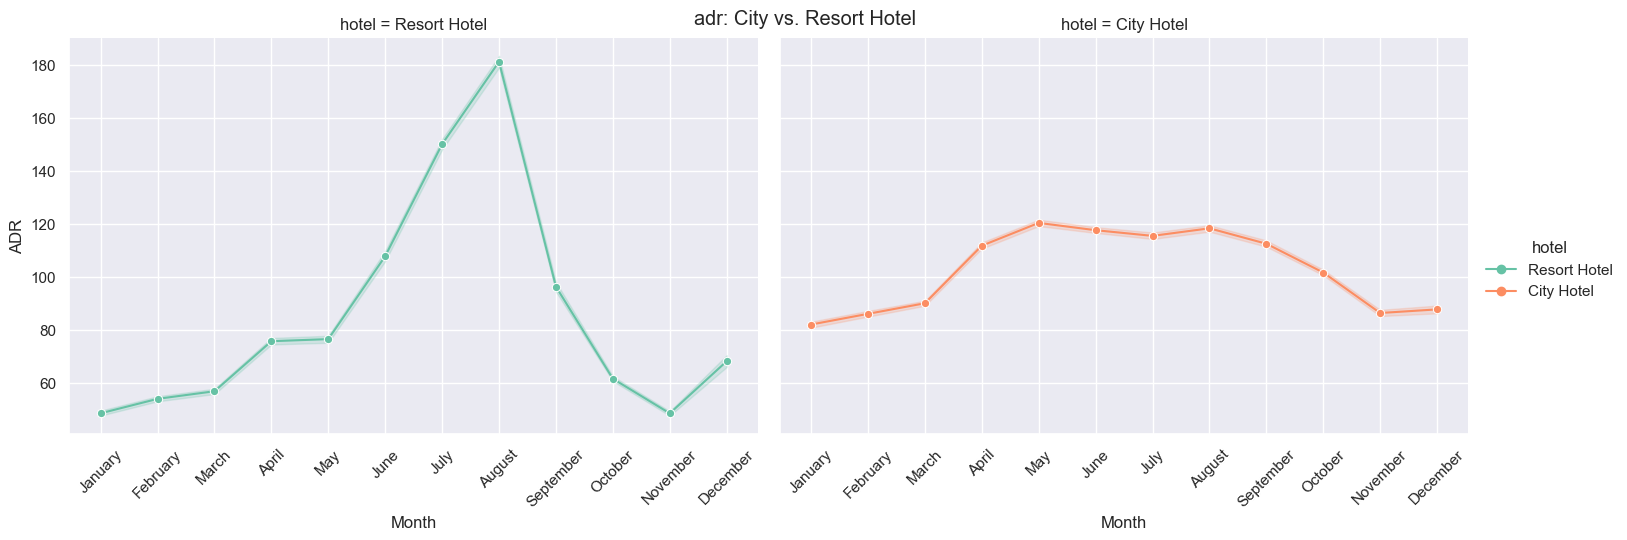

In [223]:
g2 = sns.relplot(
    data=dfnc, 
    x='arrival_month', 
    y='adr', 
    hue='hotel', 
    col='hotel',  
    kind='line', 
    marker='o',
    palette='Set2',
    height=5, 
    aspect=1.5
)

g2.fig.suptitle('adr: City vs. Resort Hotel')
g2.set_axis_labels("Month", "ADR")
g2.set_xticklabels(rotation=45)
plt.show()

##### We now know ADR trends. Next we see how it affects the total stay of the hotels' customers. 
Here's what can be observed:  <br>
**Higher the ADR, shorter are stays** <br>
We get the above conclusion because of the following reasons. <br>
1. Looking at the spread on the X-axis. The City Hotel (orange) is a dense wall that stops after 10 to 15 days, proving it is strictly a hub for quick trips. The Resort Hotel (blue) has a massive tail of guests staying 20, 40, or even 60+ days, confirming its status as a long-term getaway. <br>

2. For both hotels, the highest Average Daily Rates (the dots reaching the $400–$500 range) are heavily clustered in the 1-to-7 day window. This shows that guests are willing to pay a massive premium for a quick trip, but their daily budget drops significantly for longer vacations. <br>

3. Notice how the Resort Hotel's dots stretch out to the right? As the total_stay pushes past 20 days, the adr consistently flattens out below the $100 mark. This visually proves the hotel locks in lower, negotiated rates for extended-stay guests to secure that guaranteed long-term occupancy.


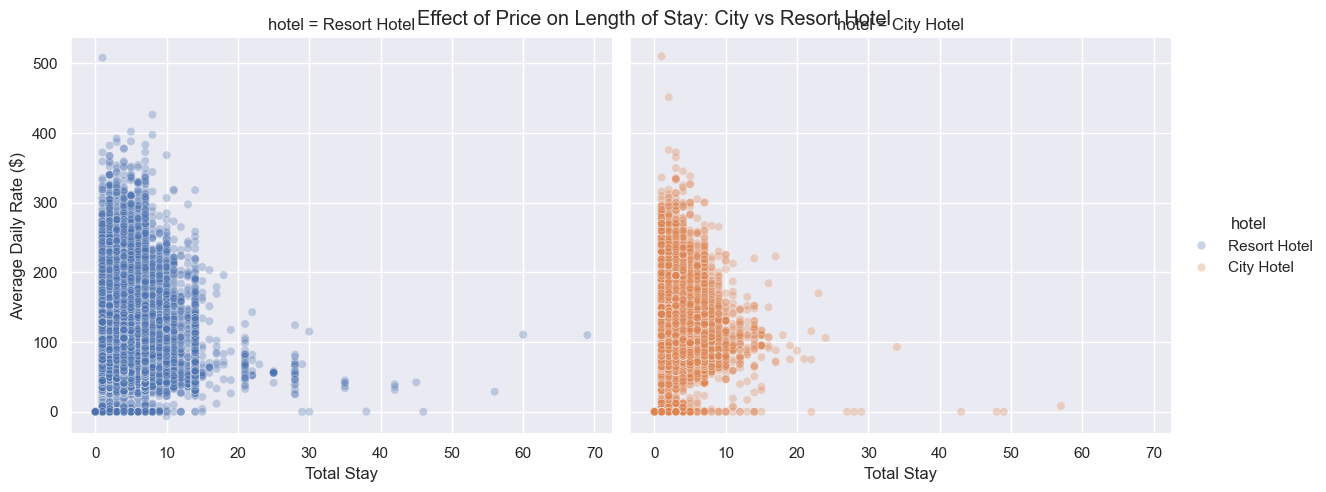

In [224]:
#Total stay trend analysis
g2 = sns.relplot(
    data=dfnc, 
    x='total_stay', 
    y='adr', 
    hue='hotel', 
    col='hotel',  
    kind='scatter', 
    alpha=0.3, 
    aspect=1.2
)

g2.fig.suptitle('Effect of Price on Length of Stay: City vs Resort Hotel')
g2.set_axis_labels("Total Stay", "Average Daily Rate ($)")
plt.show()

Find the below points concerning the Market segments:
1. Travel Agents completely run the show for the City Hotel. The data explicitly shows that 52.47% of their successful bookings come from Online TAs alone. When you combine that with Offline TAs (20.71%), nearly three-quarters of the City Hotel's entire volume relies on third-party platforms.

2. Despite being a City Hotel, the "Corporate" segment is small, making up only 5.07% of the volume. This visually proves the property is primarily booked by transient tourists hunting for deals on sites like Booking.com, not by companies booking direct blocks of rooms.

3. While the Resort Hotel also relies heavily on Online TAs, its distribution is much healthier and flatter. The gap between their Online TA, Offline TA, and Direct bookings is significantly smaller, meaning they are less vulnerable to a single platform's commission hikes. At least better than City Hotels. <br>

#### Conclusion:
So, the City Hotel is likely losing massive revenue to third-party commission fees. Management must prioritize converting that towering 52% "Online TA" block into "Direct" bookings (currently only at 10.9%) by offering on-site incentives or loyalty programs.

### Market Segments Influence on stays and ADR

market_segment
Online TA        52.47
Offline TA/TO    20.71
Direct            10.9
Groups            9.41
Corporate         5.07
Complementary     1.03
Aviation           0.4
Name: proportion, dtype: Float64


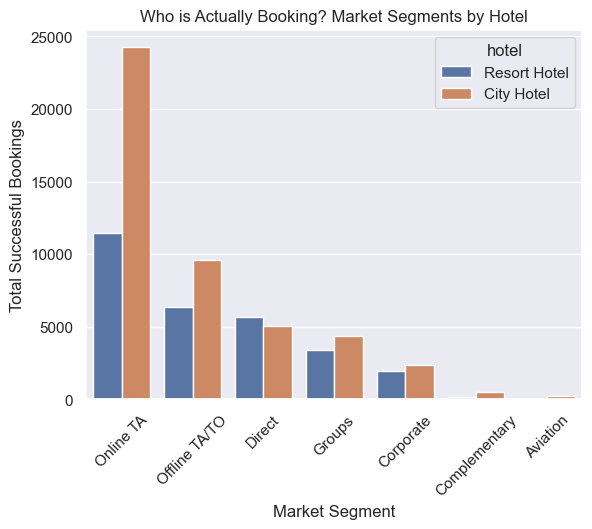

In [225]:
df_city = dfnc[dfnc['hotel'] == 'City Hotel'] 
df_market = df_city['market_segment'].value_counts(normalize=True).mul(100).round(2)
print(df_market)
sns.countplot(
    data=dfnc, 
    x='market_segment', 
    hue='hotel', 
    order=dfnc['market_segment'].value_counts().index
)
plt.title('Who is Actually Booking? Market Segments by Hotel')
plt.xlabel('Market Segment')
plt.ylabel('Total Successful Bookings')
plt.xticks(rotation=45)
plt.show()

Find the below points before we decide on a strategy:
1. Looking at the green "Direct" line in both the City and Resort panels, we see it consistently floats at or near the very top, visually proving that guests who book directly with the hotel pay the highest average daily rates year-round.

2. In the City Hotel, the "Corporate" line (orange) stays relatively flat and sits much lower than the TA lines. This confirms that corporate contracts are locked in at discounted, budget-friendly rates, while everyday tourists booking online pay a much higher premium.

3. Over at the Resort Hotel, the "Direct" and "Online TA" lines both skyrocket in August to roughly $200 a night. Meanwhile, "Offline TA/TO" (the pink line) peaks much lower, around $125. This mathematically proves that traditional travel agencies negotiate strict price caps for the summer, while online shoppers absorb the massive seasonal price surges. <br>

#### Conclusion:
Since "Direct" bookings yield the absolute highest revenue per night across both properties, the hotel must shift marketing dollars toward loyalty programs designed to convert Online TA users into Direct bookers.


<Figure size 1200x600 with 0 Axes>

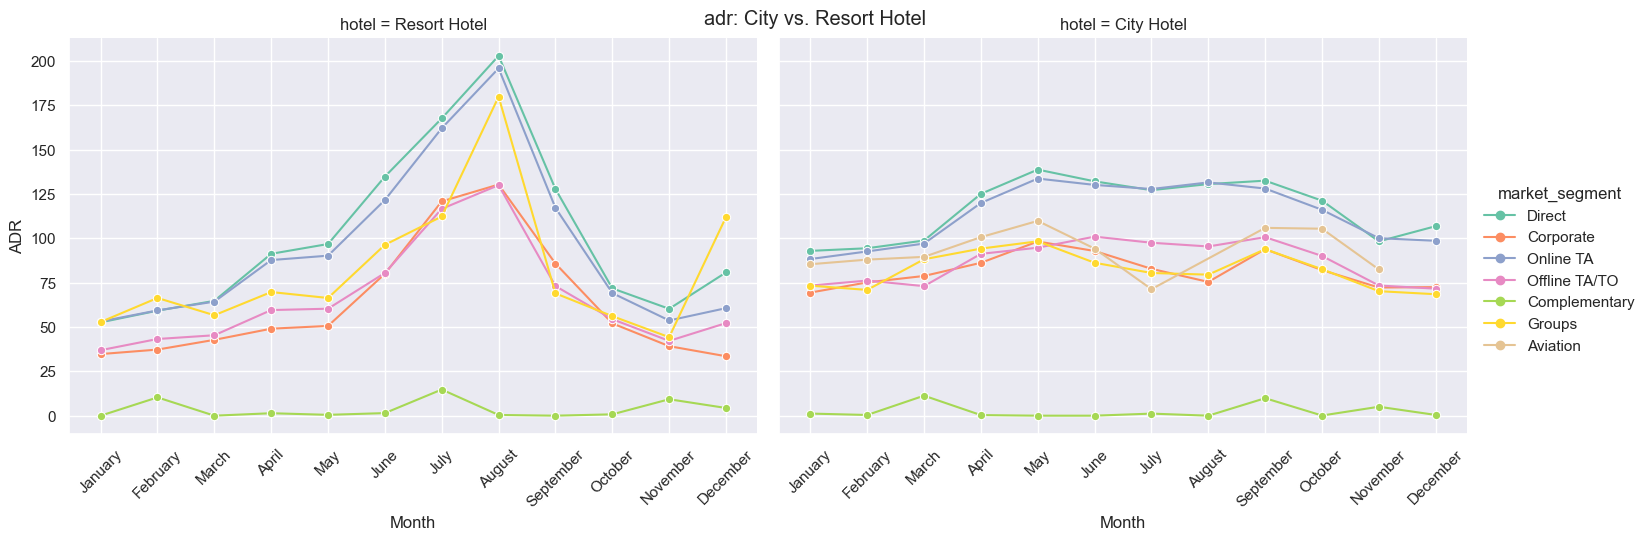

In [226]:
plt.figure(figsize=(12, 6))
g2 = sns.relplot(
    data=dfnc, 
    x='arrival_month', 
    y='adr', 
    hue='market_segment', 
    col='hotel',  
    kind='line', 
    marker='o',
    errorbar=None, 
    palette='Set2',
    height=5, 
    aspect=1.5
)

g2.fig.suptitle('adr: City vs. Resort Hotel')
g2.set_axis_labels("Month", "ADR")
g2.set_xticklabels(rotation=45)
plt.show()

Checking the ROI due to market segments. What channels are more profitable

In [227]:
roi_seg = dfnc.groupby(['hotel', 'market_segment']).agg(
    total_bookings = ('adr', 'count'), 
    avg_adr = ('adr', 'mean')
).reset_index() 
roi_seg['volume_percentage'] = roi_seg.groupby(['hotel'])['total_bookings'].transform(lambda x: (x/x.sum())*100)
roi_seg = roi_seg.sort_values(by=['hotel', 'total_bookings'], ascending=[True, False])
display(roi_seg)

,hotel,market_segment,total_bookings,avg_adr,volume_percentage
6,City Hotel,Online TA,24257,117.455069,52.472527
5,City Hotel,Offline TA/TO,9574,89.755905,20.710392
3,City Hotel,Direct,5037,119.401562,10.895994
4,City Hotel,Groups,4352,84.343787,9.414208
2,City Hotel,Corporate,2345,81.794435,5.072683
1,City Hotel,Complementary,478,2.701046,1.034005
0,City Hotel,Aviation,185,99.482054,0.40019
12,Resort Hotel,Online TA,11481,106.274003,39.674476
11,Resort Hotel,Offline TA/TO,6334,73.847517,21.888175
9,Resort Hotel,Direct,5635,108.935308,19.472666


### Booking Volume of Market Segments and Influence on ADR
1. "Direct bookings" only make up 10.9% of the volume in the City Hotel and 19.5% in the Resort Hotel. Despite having a much smaller slice of the pie, Direct bookings command the absolute highest ADR across both properties, hitting nearly $120 in the City Hotel and over $100 in the Resort Hotel.

2. Online Travel Agents (TAs) dominate your foot traffic, controlling a massive 52.5% of the City Hotel's volume and 39.7% of the Resort Hotel's volume.
    While they bring in the masses at a premium daily rate, the sheer dominance of Online TAs means the hotel is highly dependent on third-party platforms and is likely bleeding a fortune in commission fees.

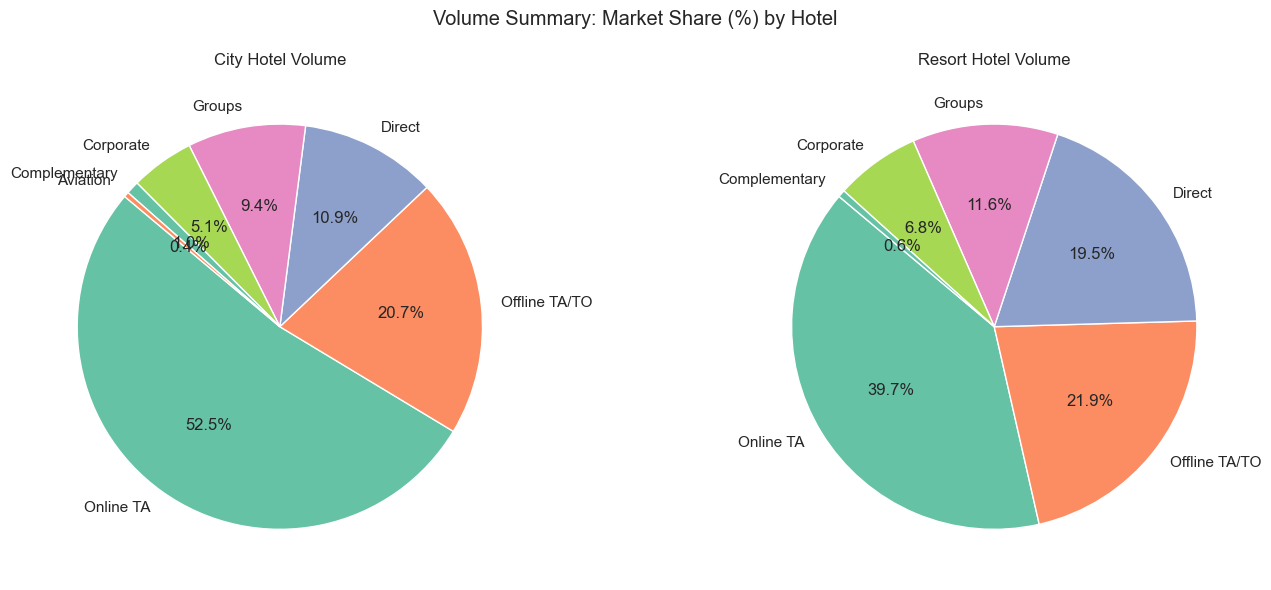

In [228]:
city_vol = dfnc[dfnc['hotel'] == 'City Hotel']['market_segment'].value_counts()
resort_col = dfnc[dfnc['hotel'] == 'Resort Hotel']['market_segment'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Volume Summary: Market Share (%) by Hotel')
colors = sns.color_palette('Set2')[0:5] 
# --- Plot A: City Hotel ---
if not city_vol.empty:
    axes[0].pie(city_vol, labels=city_vol.index, autopct='%1.1f%%', startangle=140, colors=colors)
axes[0].set_title('City Hotel Volume')

# --- Plot B: Resort Hotel ---
if not resort_col.empty:
    axes[1].pie(resort_col, labels=resort_col.index, autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('Resort Hotel Volume')

plt.tight_layout()
plt.show()

C:\Users\monke\AppData\Local\Temp\ipykernel_9496\3134175644.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


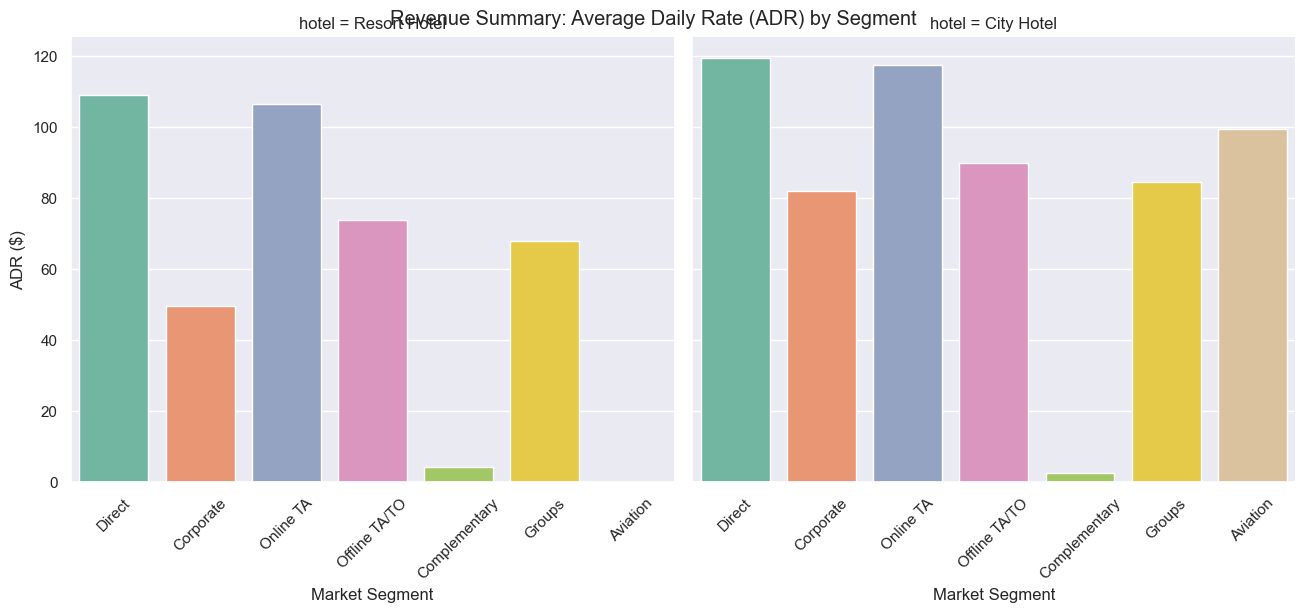

In [229]:

g = sns.catplot(
    data=dfnc,
    x='market_segment',
    y='adr',
    col='hotel', 
    kind='bar', 
    estimator='mean', 
    errorbar=None,  
    palette='Set2',
    height=5.5,
    aspect=1.2
)

# 3. Clean up titles and labels
g.fig.suptitle('Revenue Summary: Average Daily Rate (ADR) by Segment')
g.set_axis_labels("Market Segment", "ADR ($)")
g.set_xticklabels(rotation=45)

plt.show()

#### We now look into what's the deal with BB?
1. Bed & Breakfast (BB) is the absolute default setting for almost every guest. The sheer volume of BB completely obliterates FB, HB, and SC combined.
2. While BB brings in the crowds, Half Board (HB) brings in consistent premium revenue across both properties. HB averages around $120 a night for both the City and Resort hotels.

Suggestion: Since the hotel already has the massive volume locked into BB, the easiest way to spike total revenue is through aggressive upselling. The hotel should automate an email to all BB guests a week before check-in, offering them a slight discount to upgrade to Half Board (HB).

In [230]:
#SC means Self Catering
dfnc['meal'] = dfnc['meal'].replace('Undefined', 'Self Catering')

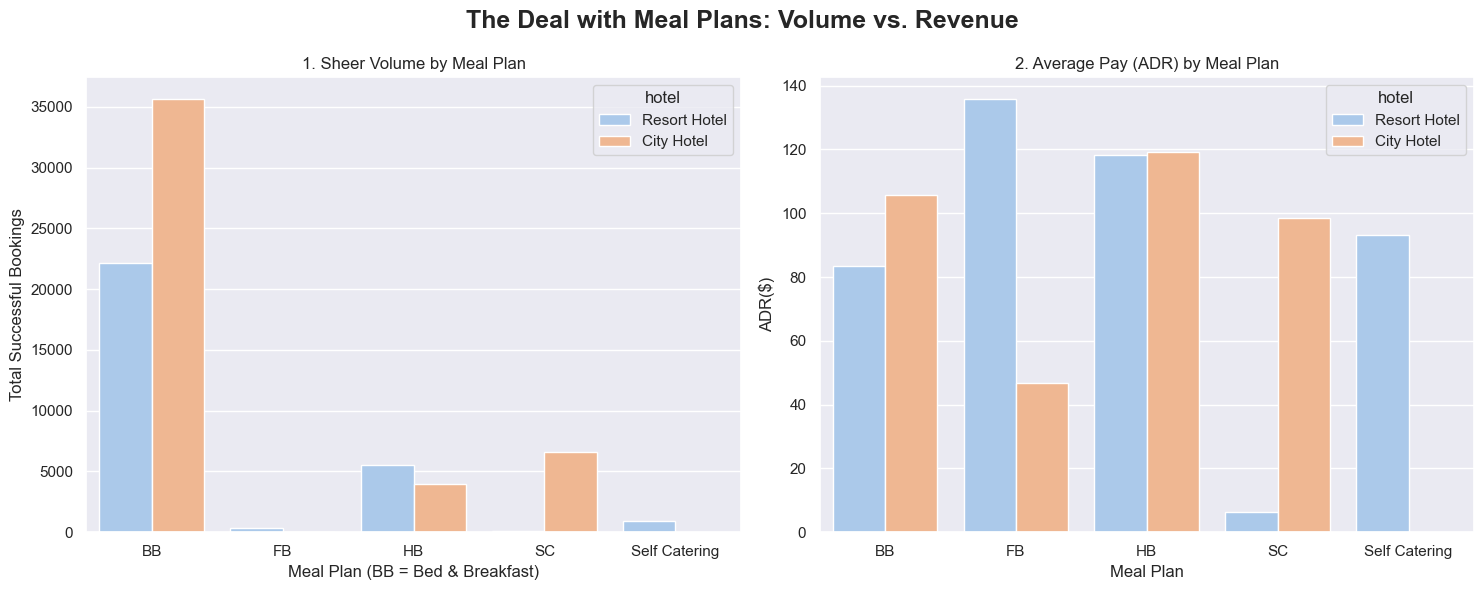

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('The Deal with Meal Plans: Volume vs. Revenue', fontsize=18, fontweight='bold')

# --- Plot A: Volume by Meal Plan ---
sns.countplot(
    data=dfnc, 
    x='meal', 
    hue='hotel', 
    palette='pastel', 
    ax=axes[0]
)
axes[0].set_title('1. Sheer Volume by Meal Plan')
axes[0].set_xlabel('Meal Plan (BB = Bed & Breakfast)')
axes[0].set_ylabel('Total Successful Bookings')

# --- Plot B: ADR by Meal Plan ---
g_bar = sns.barplot(
    data=dfnc, 
    x='meal', 
    y='adr', 
    hue='hotel', 
    estimator='mean', 
    errorbar=None, 
    palette='pastel', 
    ax=axes[1]
)
axes[1].set_title('2. Average Pay (ADR) by Meal Plan')
axes[1].set_xlabel('Meal Plan')
axes[1].set_ylabel('ADR($)')

plt.tight_layout()
plt.show()